In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functions import *
from cluster import *
from core import *
from ode_methods import *
from theory import *
from utils import *
from functools import partial
from pdb import set_trace

In [ ]:
#Define original m_ and decomposte in projection onto n and perp
#n = np.random.normal(0, 4, (N))
#m_ = np.random.normal(0, 4, (N))
#m_proj = m_.dot(n / np.linalg.norm(n)) * (n/np.linalg.norm(n))
#m_perp = m_ - m_proj

#Trade off m_proj vs. m_perp to get idealized projection mdotn
#mdotn = N * params['structure']
#beta = mdotn / (np.linalg.norm(m_proj) * np.linalg.norm(n))
#alpha = np.sqrt(np.linalg.norm(m_)**2 - beta**2 * np.linalg.norm(m_proj)**2) / np.linalg.norm(m_perp)
#m = alpha*m_perp + beta*m_proj

#processed_data = sim.mons['rnn.x'][:, 0].copy()
#time_steps = sim.mons['rnn.x'].shape[0]
#processed_data = sim.mons['rnn.x'][time_steps//2:,:].std()**2

#X = sim.mons['rnn.x']
#Phi = sim.mons['rnn.phi']

#dT_cov = int(1/ode_method.dt)

#X covariance
#cov_demeaned_x = compute_empirical_covariance((X - X.mean())[::dT_cov,:])
#cov_x = compute_empirical_covariance(X[::dT_cov,:])
#pr_dm_x = compute_participation_coefficient(cov_demeaned_x)
#pr_x = compute_participation_coefficient(cov_x)

#Phi covariance
#cov_demeaned_phi = compute_empirical_covariance((Phi - Phi.mean())[::dT_cov,:])
#cov_phi = compute_empirical_covariance(Phi[::dT_cov,:])
#pr_dm_phi = compute_participation_coefficient(cov_demeaned_phi)
#pr_phi = compute_participation_coefficient(cov_phi)

#processed_data = np.array([pr_dm_x, pr_x, pr_dm_phi, pr_phi])

In [21]:
a = np.random.normal(0, 1, 100)
np.fft.ifft(a)

array([-0.18378141+0.00000000e+00j,  0.06324795-8.72825389e-02j,
       -0.02022085+8.26454843e-02j,  0.01675029+6.17564060e-02j,
        0.04070356-1.04053764e-01j,  0.03098833+2.48412965e-02j,
        0.1217744 -7.42768249e-02j, -0.05927439+7.38260074e-02j,
        0.05516433-1.24987810e-02j,  0.02585895+8.07443062e-02j,
        0.08644547+7.66958552e-02j, -0.05897479+3.35866800e-02j,
        0.06487766+1.40956176e-02j,  0.08573526-2.20612601e-02j,
        0.04495183-1.36246041e-02j,  0.0680113 -1.05580828e-01j,
       -0.05130686+5.17109204e-02j,  0.01819205-7.29488924e-02j,
        0.04832612+2.98092719e-02j,  0.00506901-5.11670589e-02j,
        0.00200859+4.74872432e-02j,  0.08129773+8.72052613e-02j,
        0.06991956+1.44881741e-02j,  0.08425183-5.53812219e-02j,
        0.03416402-5.58747358e-02j,  0.0383417 -7.74371227e-02j,
       -0.04313014+1.14162493e-01j, -0.08818485+8.30923618e-02j,
       -0.00905899+8.83320309e-02j, -0.03572094+4.43549125e-02j,
        0.06306946+6.7797

In [33]:
def phi_prime_x(z, Delta_0):

    return 1/np.cosh(np.sqrt(Delta_0)*z)**2 * np.sqrt(Delta_0)

def compute_alpha(g):

    Delta_0 = solve_for_Delta_0(g=g, Delta_0_init=70)
    f = partial(phi_prime_x, Delta_0=Delta_0)
    return gaussian_integral(f)

#def compute_phi_pr(g):

g = 2.2
T = 5
dT = 0.01
alpha = compute_alpha(g)
Delta_0 = solve_for_Delta_0(g=g, Delta_0_init=70)
time, Delta_T, _ = solve_for_Delta_T(g=g, Delta_0=Delta_0, T=T, dT=dT)
Delta_T = np.concatenate([np.flip(Delta_T[:-1]), Delta_T])

Delta_omega = np.fft.fft(Delta_T)
omega = np.fft.fftfreq(n=2*int(T/dT)-1,d=dT)
omega_1 = omega
omega_2 = omega

nu = alpha**2 * g**2
gamma_phi = alpha**4
Phi_phi = np.multiply.outer((1 + omega_1**2), (1 + omega_2**2)) / (nu**2)

F1 = gamma_phi * (1 + nu**2 / (np.multiply.outer((1 + omega_1**2), (1 + omega_2**2)) - nu**2))
F2 = 1 + 2 * np.real(nu / (np.multiply.outer((1 + (1j)*omega_1), (1 + (1j)*omega_2)) - nu)) * Phi_phi
F3 = np.multiply.outer(Delta_omega, Delta_omega)

pp_f = F1 * F2 * F3
pp = np.fft.ifft(np.fft.ifft(pp_f, axis=0), axis=0)
Delta_0**2 / (Delta_0**2 + np.abs(pp[0,0]))


0.07660502790723414

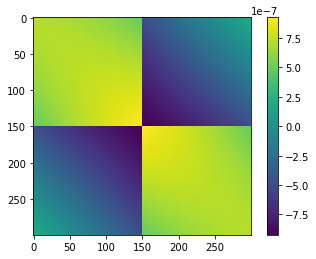

In [51]:
plt.imshow(np.real(pp)[350:650, 350:650])#, vmin=-10, vmax=10)
plt.colorbar()

In [31]:
gs = []
for g in range(20):
    
    gs.append(compute_phi_pr(g))

/Users/omarschall/opt/anaconda3/envs/v-rtrl/lib/python3.7/site-packages/ipykernel_launcher.py:28: RuntimeWarning: divide by zero encountered in true_divide
/Users/omarschall/opt/anaconda3/envs/v-rtrl/lib/python3.7/site-packages/ipykernel_launcher.py:31: RuntimeWarning: invalid value encountered in multiply
/Users/omarschall/mft-theory/theory/basic_dmft.py:77: RuntimeWarning: invalid value encountered in sqrt
  inner_integrand = np.tanh(np.add.outer(np.sqrt(Delta) * gauss_points,


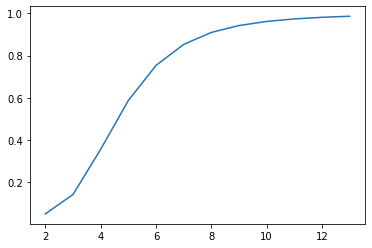

In [32]:
plt.plot(range(20), gs)

In [27]:
Delta_0**2

6.283889168461786

In [3]:
g = 5
omega, Delta_omega = compute_Delta_omega(g, T=5)

In [9]:
pp_f = psi_phi_in_fourier_space(omega, omega, compute_alpha(g), g, Delta_omega)

In [10]:
pp = np.fft.ifft(np.fft.ifft(pp_f, axis=0), axis=0)

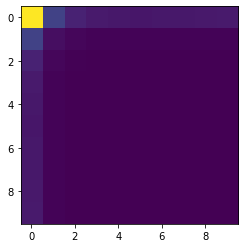

In [15]:
plt.imshow(np.abs(pp)[:10, :10])

In [ ]:
import numpy as np
from .basic_dmft import *
from .theory_utils import gaussian_integral
from functools import partial

def psi_phi_in_fourier_space(omega_1, omega_2, alpha, g, Delta_omega):
    """Calculate the cross-covariance in Fourier space for the activations, ie
    Eq. 6 in David's paper with a = phi.

    The discretization used in the fft of Delta_omega must match that of any
    vectorized inputs to the arguments omega_1 and omega_2."""

    nu = alpha**2 * g**2
    gamma_phi = alpha**4
    Phi_phi = np.multiply.outer((1 + omega_1**2), (1 + omega_2**2)) / (nu**2)

    F1 = gamma_phi * (1 + nu**2 / (np.multiply.outer((1 + omega_1**2), (1 + omega_2**2)) - nu**2))
    F2 = 1 + 2 * np.real(nu / (np.multiply.outer((1 + (1j)*omega_1), (1 + (1j)*omega_2)) - nu)) * Phi_phi
    F3 = np.multiply.outer(Delta_omega, Delta_omega)

    return F1 * F2 * F3

def compute_Delta_omega(g):

    Delta_0 = solve_for_Delta_0(g=g, Delta_0_init=70)
    time, Delta_T, _ = solve_for_Delta_T(g=g, Delta_0=Delta_0, T=20)
    return np.fft.fft(Delta_T)

def phi_prime_x(z, Delta_0):

    return 1/np.cosh(np.sqrt(Delta_0)*z)**2 * np.sqrt(Delta_0)

def compute_alpha(g):

    Delta_0 = solve_for_Delta_0(g=g, Delta_0_init=70)
    f = partial(phi_prime_x, Delta_0=Delta_0)
    return gaussian_integral(f)